# Busy 16-s window: spectrogram + DAS annotations

Renders a 16-s excerpt of a ~6-min recording as **4 rows x 4 s**, with the DAS segments
from `all_calls_2026_02.csv` overlaid as colored ribbons.

Two steps:
1. Rank every `(exp, file_num, channel)` in 2026_02 by **total calls in the file**.
2. Pick the 16-s display window inside the chosen file (most call classes, then most
   calls). Display only — it does not affect step 1.

Current selection: **exp 497, file 148, channel 30 (underground), 4-20 s — 107 calls in
the window**, all five classes. This is the densest 16 s anywhere in 2026_02.

Caveat worth knowing: that file holds 289 calls overall (rank 648 / 8068), so the window
is a burst — 37% of the file's calls inside 4.4% of its duration. Alternatives, both set
with `T_START = None` to auto-pick their window:
- `EXP, FILE_NUM = 552, 55` — 741 calls in the file, 69 in the window; a busy stretch
  that is typical of the recording rather than an outlier.
- `EXP, FILE_NUM = 493, 24` — busiest file overall (927 calls), but ~64% warble.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from matplotlib.patches import Patch
from scipy.signal import spectrogram

REPO_ROOT = Path("/mnt/home/gginosar/repos/gerbil_vocalization_analysis")
sys.path.insert(0, str(REPO_ROOT / "scripts" / "utils"))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from spectrogram_viz import COLOR_MAP
from scripts.pipeline.audio_processing_config import get_experiment_month

AUDIO_ROOT = Path(
    "/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio"
)
ALL_CALLS_DIR = AUDIO_ROOT / "all_calls"
OUT_DIR = REPO_ROOT / "figures" / "busy_window"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET = "2026_02"

# --- which ~6-min file to use (chosen on TOTAL calls in the file) -----------
EXP = 497
FILE_NUM = 148
CHANNEL = 30

# --- the 16-s excerpt to display -------------------------------------------
T_START = 4.0        # None -> auto-pick the best window inside the file
ROW_S = 4.0          # seconds per row
N_ROWS = 4           # -> 16 s total

CALL_TYPES = ["alarm", "high-freq", "newborn", "stacks", "warble"]

# --- display ---------------------------------------------------------------
MIN_FREQ = 1_000
MAX_FREQ = 60_000
NPERSEG = 512        # ~4 ms at 125 kHz - short calls stay crisp over a 4-s row
NOVERLAP = 448
# dB is referenced to the 99.9th percentile of the window rather than the single
# loudest frame, so one transient can't wash out the other 16 s.
DB_REF_PCT = 99.9
VMIN, VMAX = -30.0, 2.0
ROW_W, ROW_H = 18.0, 2.8

print(f"figures -> {OUT_DIR}")

figures -> /mnt/home/gginosar/repos/gerbil_vocalization_analysis/figures/busy_window


## Step 1 - rank whole files by total call count

Every `(exp, file_num, channel)` is one ~6-min recording. Ranked by total DAS calls in
the file; the per-class columns show how balanced each file is. Use this to set
`EXP` / `FILE_NUM` / `CHANNEL` above.

In [2]:
calls = pd.read_csv(ALL_CALLS_DIR / f"all_calls_{DATASET}.csv")
print(f"{len(calls):,} calls in {DATASET}")
print(calls["event_type"].value_counts().to_string(), "\n")

per_file = (
    calls
    .groupby(["exp", "file_num", "channel"])
    .agg(
        n_calls=("event_type", "size"),
        n_types=("event_type", "nunique"),
        span_s=("start_time_file_sec", lambda s: round(s.max() - s.min(), 1)),
        location=("assigned_location", lambda s: s.mode().iat[0]),
    )
)
# per-class counts alongside the totals
by_type = (
    calls.groupby(["exp", "file_num", "channel", "event_type"]).size()
    .unstack("event_type", fill_value=0)
    .reindex(columns=CALL_TYPES, fill_value=0)
)
per_file = per_file.join(by_type).sort_values("n_calls", ascending=False).reset_index()

print(f"{len(per_file):,} files; busiest:")
per_file.head(15)

894,036 calls in 2026_02
event_type
warble       414324
stacks       216303
high-freq    207562
newborn       51312
alarm          4535 



8,068 files; busiest:


,exp,file_num,channel,n_calls,n_types,span_s,location,alarm,high-freq,newborn,stacks,warble
0,493,24,30,927,5,354.1,underground,3,42,1,286,595
1,495,0,30,920,4,353.7,underground,2,32,0,436,450
2,494,13,30,854,5,350.6,underground,1,35,3,304,511
3,555,104,30,815,5,355.0,underground,4,259,59,306,187
4,555,145,30,798,4,355.8,underground,0,21,16,734,27
5,493,47,30,784,4,339.9,underground,7,28,0,253,496
6,496,2,30,781,4,352.5,underground,0,13,4,366,398
7,526,50,30,772,4,355.1,underground,0,463,34,34,241
8,499,5,30,760,5,355.3,underground,3,55,1,469,232
9,516,3,20,748,4,353.0,arena_2,0,65,3,1,679


## Step 2 - pick the 16-s display window inside that file, load audio

The window is chosen for legibility only (most call classes, then most calls); the file
itself was already chosen in step 1. Set `T_START` explicitly above to override.

Only the needed samples are read (`soundfile` seeks); the wavs are ~180 MB each.

In [3]:
WINDOW_S = ROW_S * N_ROWS

file_calls = calls[(calls["exp"] == EXP)
                   & (calls["file_num"] == FILE_NUM)
                   & (calls["channel"] == CHANNEL)].sort_values("start_time_file_sec")
if file_calls.empty:
    raise ValueError(f"no calls for exp {EXP} file {FILE_NUM} ch {CHANNEL}")
print(f"file total: {len(file_calls)} calls over "
      f"{file_calls['start_time_file_sec'].max():.0f} s "
      f"({file_calls['assigned_location'].mode().iat[0]})")
print(file_calls["event_type"].value_counts().to_string())

if T_START is None:
    onsets = file_calls["start_time_file_sec"].to_numpy()
    types = file_calls["event_type"].to_numpy()
    # candidate windows start at each onset; score = (n classes, n calls)
    ends = np.searchsorted(onsets, onsets + WINDOW_S, side="right")
    best_score, best_t0 = (-1, -1), onsets[0]
    for i, j in enumerate(ends):
        score = (len(set(types[i:j])), j - i)
        if score > best_score:
            best_score, best_t0 = score, onsets[i]
    T_START = float(np.floor(best_t0 * 10) / 10)
    print(f"\nauto window -> t={T_START:.1f} s "
          f"({best_score[1]} calls, {best_score[0]} classes)")

T_END = T_START + WINDOW_S

wav_path = (
    AUDIO_ROOT / get_experiment_month(EXP) / str(EXP) / "Averaged_wavs_w_annotations"
    / f"channel_{CHANNEL}_file_{FILE_NUM:03d}.wav"
)
info = sf.info(wav_path)
fs = info.samplerate
print(f"\n{wav_path.name}  fs={fs} Hz  dur={info.duration:.1f} s")

PAD_S = 0.25  # read a little extra so each row's spectrogram edges are clean
read_start = max(0.0, T_START - PAD_S)
read_stop = min(info.duration, T_END + PAD_S)
x, _ = sf.read(
    wav_path,
    start=int(read_start * fs),
    stop=int(read_stop * fs),
    dtype="float32",
    always_2d=True,
)
x = x[:, 0]
print(f"read {len(x):,} samples ({read_start:.2f}-{read_stop:.2f} s)")

segs = file_calls[(file_calls["stop_time_file_sec"] > T_START)
                  & (file_calls["start_time_file_sec"] < T_END)].copy()
print(f"\n{len(segs)} DAS segments in {T_START:.1f}-{T_END:.1f} s")
print(segs["event_type"].value_counts().to_string())

file total: 289 calls over 356 s (underground)
event_type
stacks       141
warble       126
high-freq     17
newborn        4
alarm          1

channel_30_file_148.wav  fs=125000 Hz  dur=360.0 s
read 2,062,500 samples (3.75-20.25 s)

107 DAS segments in 4.0-20.0 s
event_type
stacks       59
warble       43
high-freq     2
newborn       2
alarm         1


## Spectrogram once, sliced per row

One STFT over the whole 16 s keeps the rows perfectly consistent; each row just
plots its own time slice. Annotation ribbons sit in a reserved strip at the top of
each panel so they never cover the calls themselves.

spectrogram (241, 32219)  (0.51 ms hop)


saved busy16s_2026_02_exp497_file148_ch30_t4.png / .pdf


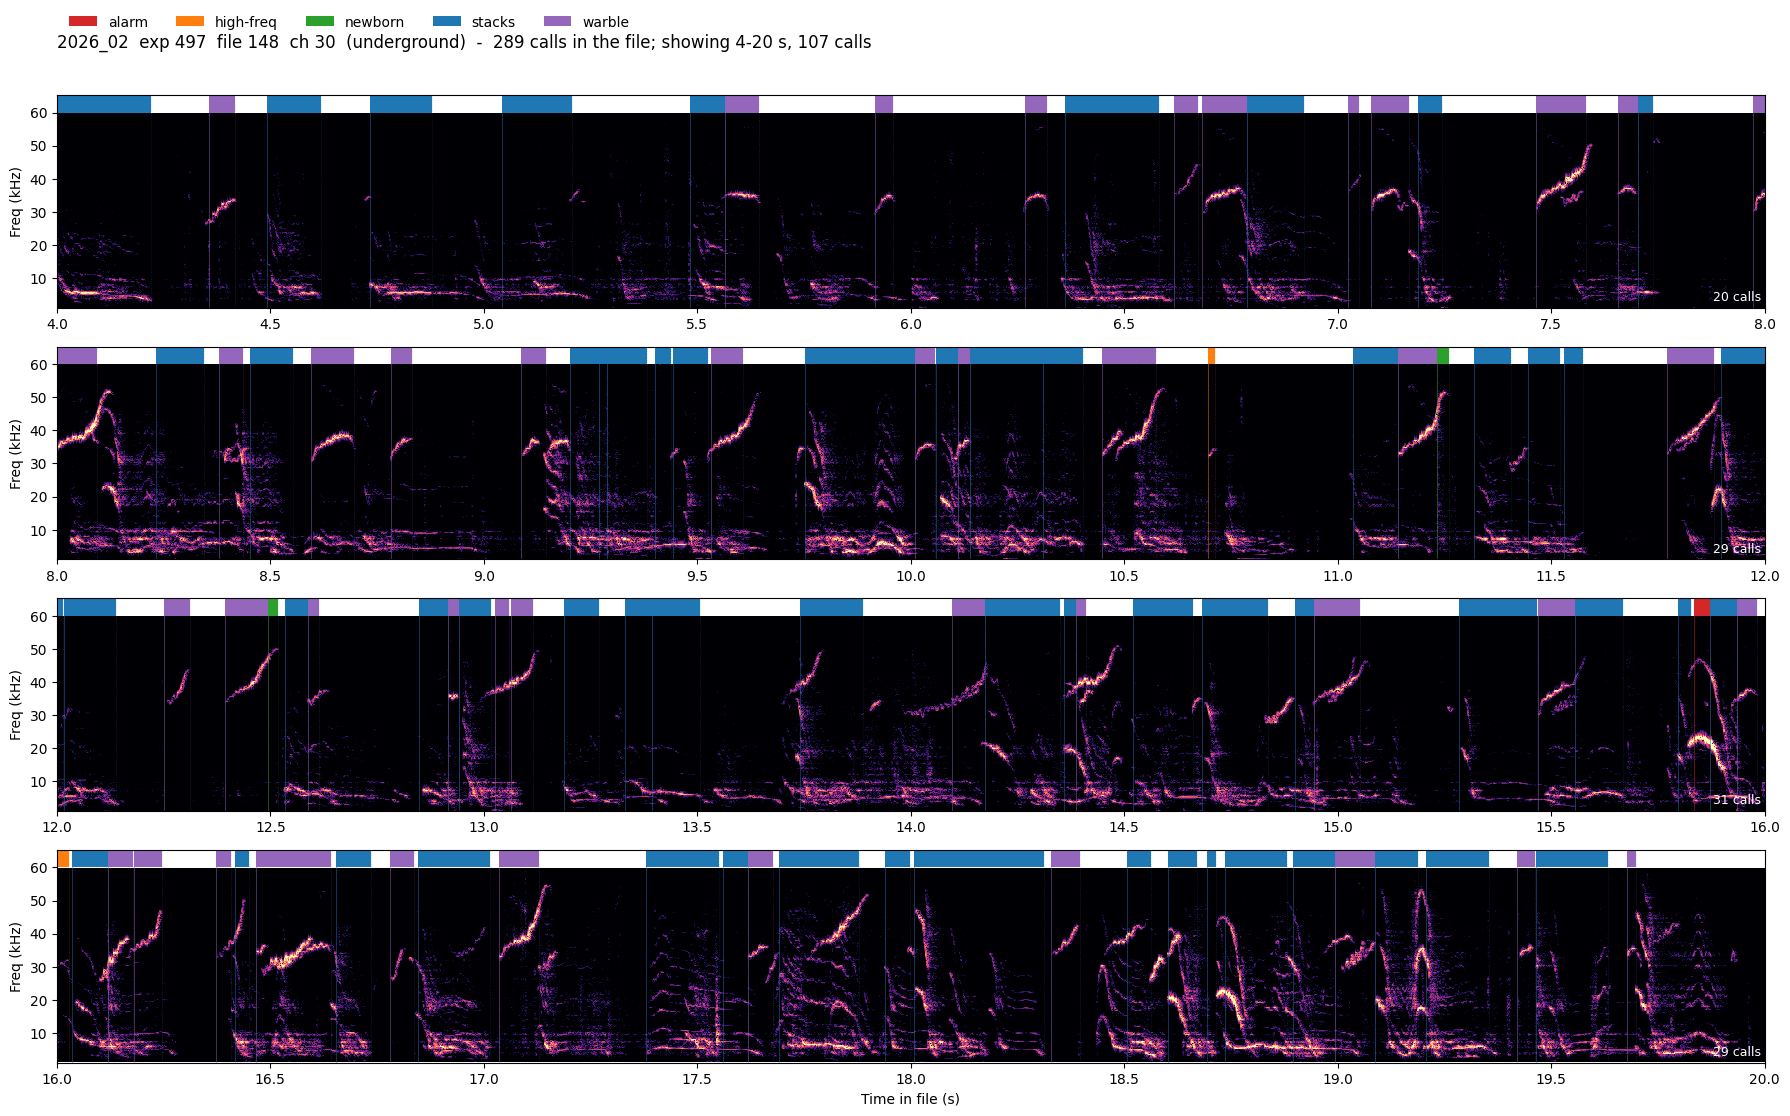

In [4]:
f, t, Sxx = spectrogram(
    x, fs=fs, nperseg=NPERSEG, noverlap=NOVERLAP,
    scaling="spectrum", mode="magnitude",
)
t = t + read_start  # -> absolute time within the wav file
fmask = (f >= MIN_FREQ) & (f <= MAX_FREQ)
f_khz = f[fmask] / 1000.0

S = 20.0 * np.log10(Sxx[fmask, :] + 1e-12)
S -= np.percentile(S, DB_REF_PCT)
print(f"spectrogram {S.shape}  ({1000 * (t[1] - t[0]):.2f} ms hop)")

# annotation ribbon geometry, in kHz on the frequency axis
F_TOP = MAX_FREQ / 1000.0
RIBBON_H = 0.09 * (F_TOP - MIN_FREQ / 1000.0)
RIBBON_LO = F_TOP
RIBBON_HI = F_TOP + RIBBON_H

fig, axes = plt.subplots(N_ROWS, 1, figsize=(ROW_W, ROW_H * N_ROWS))
axes = np.atleast_1d(axes)

for i, ax in enumerate(axes):
    t0 = T_START + i * ROW_S
    t1 = t0 + ROW_S
    m = (t >= t0 - 0.02) & (t <= t1 + 0.02)
    ax.pcolormesh(t[m], f_khz, S[:, m], shading="auto",
                  vmin=VMIN, vmax=VMAX, cmap="magma", rasterized=True)

    row_segs = segs[(segs["stop_time_file_sec"] > t0)
                    & (segs["start_time_file_sec"] < t1)]
    for _, r in row_segs.iterrows():
        color = COLOR_MAP.get(r["event_type"], "tab:gray")
        on = max(float(r["start_time_file_sec"]), t0)
        off = min(float(r["stop_time_file_sec"]), t1)
        # ribbon bar above the spectrogram
        ax.add_patch(plt.Rectangle((on, RIBBON_LO), off - on, RIBBON_H,
                                   facecolor=color, edgecolor="none", clip_on=False))
        # onset/offset ticks tying the ribbon down to the call itself
        ax.axvline(on, color=color, lw=0.6, alpha=0.55)
        ax.axvline(off, color=color, lw=0.6, alpha=0.30, ls=":")

    ax.set_xlim(t0, t1)
    ax.set_ylim(MIN_FREQ / 1000.0, RIBBON_HI)
    ax.set_yticks([10, 20, 30, 40, 50, 60])
    ax.set_ylabel("Freq (kHz)")
    ax.set_xlabel("Time in file (s)" if i == N_ROWS - 1 else "")
    ax.text(0.998, 0.02, f"{len(row_segs)} calls", transform=ax.transAxes,
            ha="right", va="bottom", color="w", fontsize=9)

present = [c for c in CALL_TYPES if c in set(segs["event_type"])]
axes[0].legend(
    handles=[Patch(facecolor=COLOR_MAP[c], label=c) for c in present],
    loc="lower left", bbox_to_anchor=(0, 1.25), ncol=len(present),
    frameon=False, fontsize=10,
)
axes[0].set_title(
    f"{DATASET}  exp {EXP}  file {FILE_NUM}  ch {CHANNEL}"
    f"  ({file_calls['assigned_location'].mode().iat[0]})"
    f"  -  {len(file_calls)} calls in the file;"
    f" showing {T_START:.0f}-{T_END:.0f} s, {len(segs)} calls",
    loc="left", pad=34, fontsize=12,
)

fig.tight_layout()
stem = f"busy16s_{DATASET}_exp{EXP}_file{FILE_NUM}_ch{CHANNEL}_t{T_START:.0f}"
fig.savefig(OUT_DIR / f"{stem}.png", dpi=200, bbox_inches="tight")
fig.savefig(OUT_DIR / f"{stem}.pdf", bbox_inches="tight")
print(f"saved {stem}.png / .pdf")
plt.show()